In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon')
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon\raman_simulation')
import useful_funcs
import simulation as s
from matplotlib.colors import TwoSlopeNorm
import scienceplots
import matplotlib.colors as colors
import matplotlib.ticker as ticker

In [2]:
sim = s.sim()
sim.ls_order = 2
sim.get_f()

In [3]:
Pb_bank = sim.RID_rpi*1e-3
sim.analytics(Pb_bank,  sim_resonance = 2*np.pi*sim.res_4)

In [10]:
δ1 = sim.ω_pred - sim.ω01_bank
δ2 = -sim.ω_pred + sim.ω01_bank + sim.ω12_bank
Ω = -sim.Ω03_4 - sim.Ω03_6

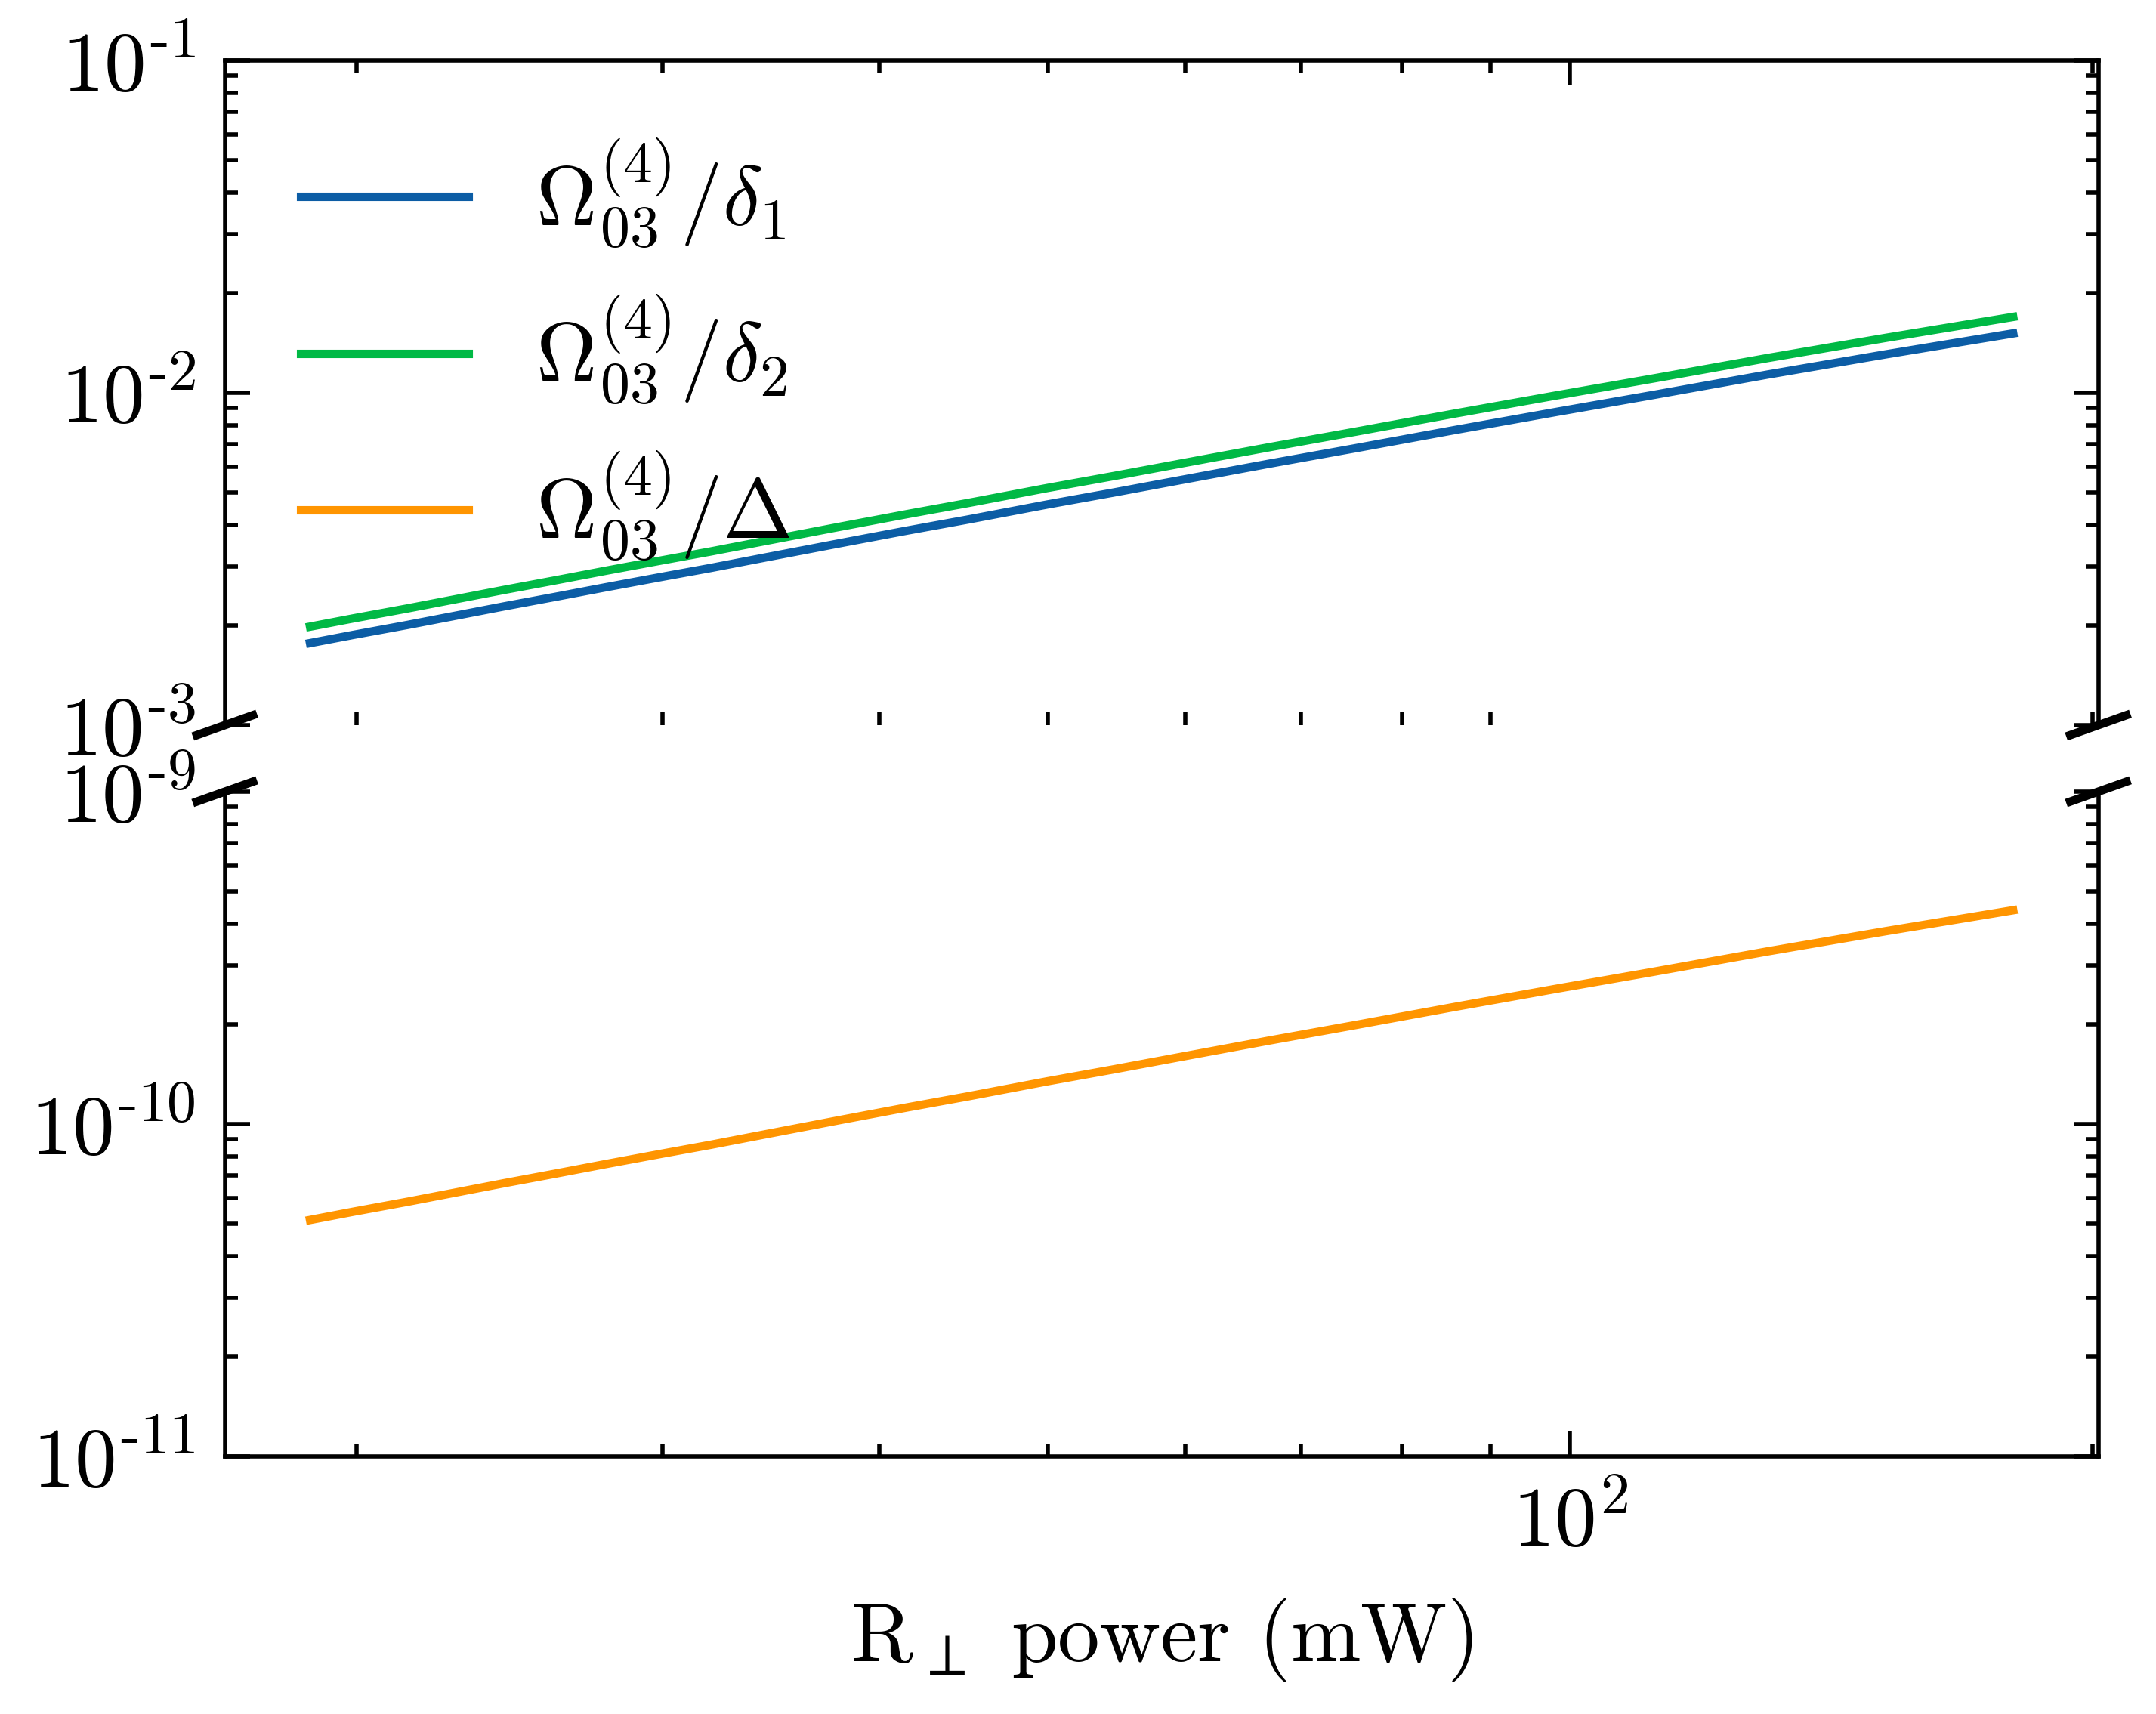

In [13]:
with plt.style.context(['science','no-latex']):
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        sharex=True,
        figsize=(4, 3),
        gridspec_kw={"height_ratios": [1, 1], "hspace": 0.1},
        dpi=800
    )

    # --------------------------
    # TOP AXIS (high values)
    # --------------------------
    ax1.set_yscale('log')
    ax1.set_ylim(1e-3, 1e-1)
    ax1.plot(sim.RID_rpi, Ω/δ1, label=r'$\Omega_{03}^{(4)}/\delta_1$')
    ax1.plot(sim.RID_rpi, Ω/δ2, label=r'$\Omega_{03}^{(4)}/\delta_2$')
    ax1.plot(sim.RID_rpi, -Ω/sim.Δ, label=r'$\Omega_{03}^{(4)}/\Delta$')
    ax1.axhline(1, color='black', lw=0.8)

    # Remove bottom spine and all x-ticks
    ax1.spines['bottom'].set_visible(False)
    ax1.tick_params(bottom=False, labelbottom=False)
    ax1.xaxis.set_ticks([])                 
    ax1.xaxis.set_minor_locator(plt.NullLocator())  
    ax2.set_yscale('log')
    ax2.set_ylim(1e-11, 1e-9)
    ax2.plot(sim.RID_rpi, Ω/δ1)
    ax2.plot(sim.RID_rpi, Ω/δ2)
    ax2.plot(sim.RID_rpi, -Ω/sim.Δ)
    ax2.spines['top'].set_visible(False)
    ax2.tick_params(top=False)
    ax2.xaxis.set_tick_params(which='both', top=False)
    ax2.set_xlabel(r"R$_\perp$ power (mW)")
    ax2.set_xscale('log')
    d = 0.015
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
    ax1.plot((-d, +d), (-d, +d), **kwargs)
    ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
    kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False)
    ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)
    ax1.legend(frameon=False, loc = 'upper left')
    plt.subplots_adjust(hspace=3)
    #ax1.set_title('Validity of\nadiabatic elimination')
    plt.show()